# Bước 6: Trực Quan Hóa Mối Quan Hệ Dữ Liệu

Trực quan hóa giúp khám phá mẫu, xu hướng và mối quan hệ trong dữ liệu.

**Mục tiêu:**
- Univariate Analysis (phân tích đơn biến)
- Bivariate Analysis (phân tích hai biến)
- Multivariate Analysis (phân tích đa biến)

## 6.1 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("✅ Thư viện đã được import thành công!")

✅ Thư viện đã được import thành công!


## 6.2 Tải dữ liệu

In [2]:
try:
    df = pd.read_pickle('outputs/df_step5.pkl')
    print("✅ Đã tải dữ liệu từ Bước 5")
except:
    DATA_PATH = Path("../data/raw/accepted_2007_to_2018Q4.csv")
    df = pd.read_csv(DATA_PATH, nrows=50000, low_memory=False)
    print("📂 Đã tải dữ liệu gốc")

print(f"📊 Kích thước: {df.shape[0]:,} hàng × {df.shape[1]} cột")

# Tính toán thống kê để chú thích
n_rows = len(df)

✅ Đã tải dữ liệu từ Bước 5
📊 Kích thước: 50,000 hàng × 155 cột


## 6.3 Univariate Analysis - Phân tích đơn biến

In [3]:
print("=" * 70)
print("📊 UNIVARIATE ANALYSIS - PHÂN TÍCH ĐƠN BIẾN")
print("=" * 70)
print("Tập trung vào phân bố của từng biến riêng lẻ")

📊 UNIVARIATE ANALYSIS - PHÂN TÍCH ĐƠN BIẾN
Tập trung vào phân bố của từng biến riêng lẻ


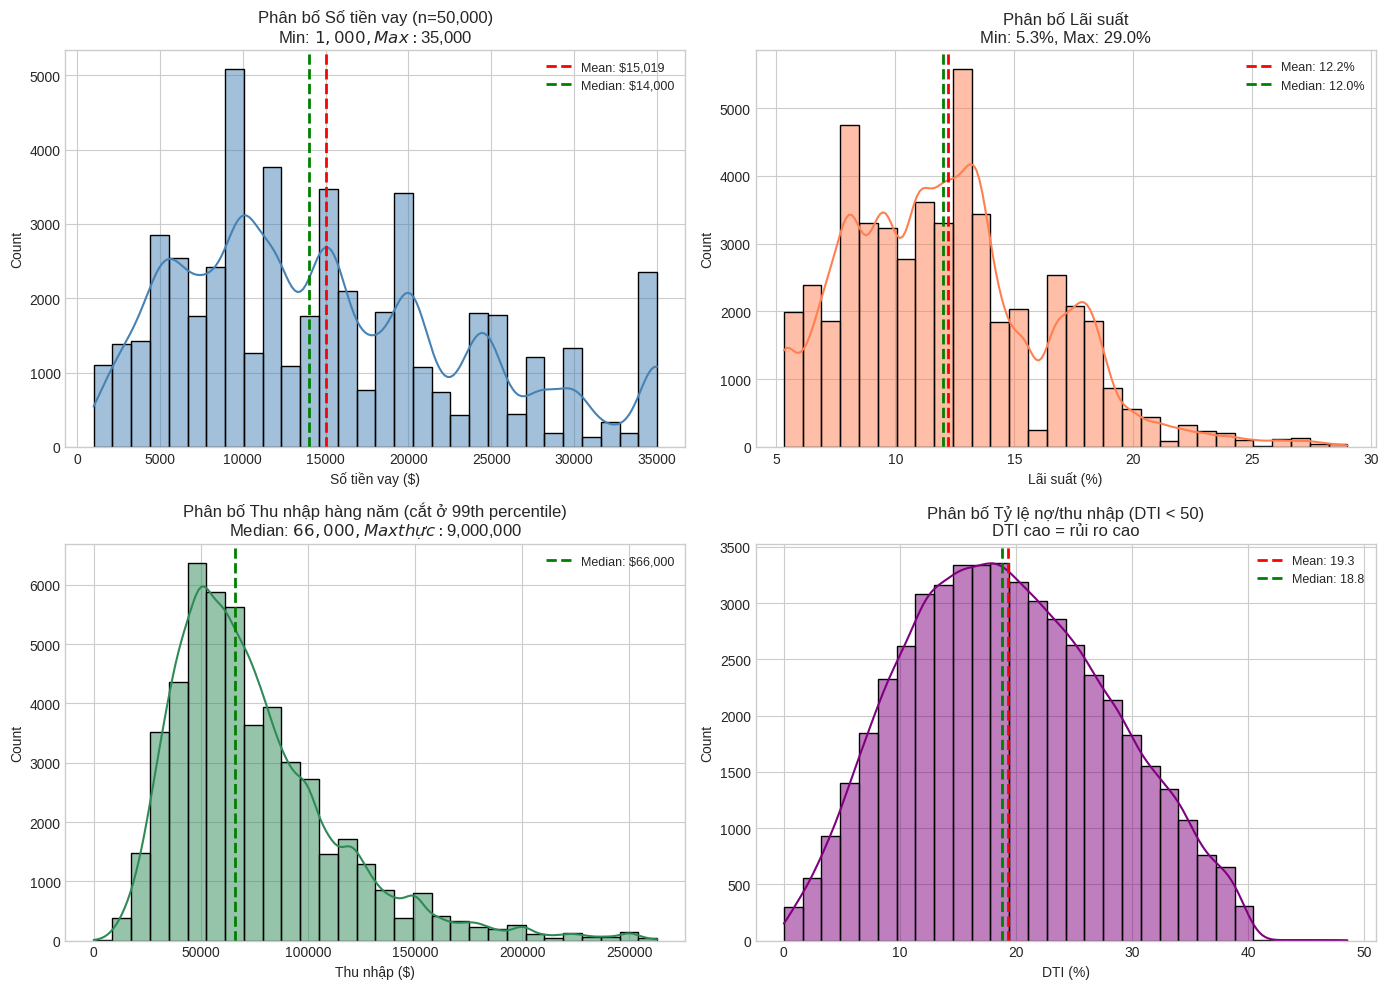


📌 INSIGHT TỪ UNIVARIATE ANALYSIS:
   • Số tiền vay: Trung bình $15,019, phổ biến nhất $10,000-$20,000
   • Lãi suất: Trung bình 12.2%, dao động 5.3%-29.0%
   • Thu nhập: Trung vị $66,000, có outliers rất cao (> $1M)
   • DTI: Trung bình 19.3%, DTI > 35 được coi là rủi ro



In [4]:
# Tính thống kê cho chú thích
loan_mean = df['loan_amnt'].mean()
loan_median = df['loan_amnt'].median()
int_mean = df['int_rate'].mean()
int_median = df['int_rate'].median()
inc_mean = df['annual_inc'].mean()
inc_median = df['annual_inc'].median()
dti_mean = df['dti'].mean()
dti_median = df['dti'].median()

# Histogram cho các biến số quan trọng
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loan Amount
if 'loan_amnt' in df.columns:
    ax = axes[0, 0]
    sns.histplot(df['loan_amnt'], bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(loan_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: ${loan_mean:,.0f}')
    ax.axvline(loan_median, color='green', linestyle='--', linewidth=2, label=f'Median: ${loan_median:,.0f}')
    ax.set_title(f'Phân bố Số tiền vay (n={n_rows:,})\nMin: ${df["loan_amnt"].min():,.0f}, Max: ${df["loan_amnt"].max():,.0f}')
    ax.set_xlabel('Số tiền vay ($)')
    ax.legend(fontsize=9)

# Interest Rate
if 'int_rate' in df.columns:
    ax = axes[0, 1]
    sns.histplot(df['int_rate'], bins=30, kde=True, ax=ax, color='coral')
    ax.axvline(int_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {int_mean:.1f}%')
    ax.axvline(int_median, color='green', linestyle='--', linewidth=2, label=f'Median: {int_median:.1f}%')
    ax.set_title(f'Phân bố Lãi suất\nMin: {df["int_rate"].min():.1f}%, Max: {df["int_rate"].max():.1f}%')
    ax.set_xlabel('Lãi suất (%)')
    ax.legend(fontsize=9)

# Annual Income (giới hạn 99th percentile)
if 'annual_inc' in df.columns:
    ax = axes[1, 0]
    p99 = df['annual_inc'].quantile(0.99)
    data = df[df['annual_inc'] < p99]['annual_inc']
    sns.histplot(data, bins=30, kde=True, ax=ax, color='seagreen')
    ax.axvline(inc_median, color='green', linestyle='--', linewidth=2, label=f'Median: ${inc_median:,.0f}')
    ax.set_title(f'Phân bố Thu nhập hàng năm (cắt ở 99th percentile)\nMedian: ${inc_median:,.0f}, Max thực: ${df["annual_inc"].max():,.0f}')
    ax.set_xlabel('Thu nhập ($)')
    ax.legend(fontsize=9)

# DTI
if 'dti' in df.columns:
    ax = axes[1, 1]
    dti_clean = df['dti'].dropna()
    sns.histplot(dti_clean[dti_clean < 50], bins=30, kde=True, ax=ax, color='purple')
    ax.axvline(dti_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {dti_mean:.1f}')
    ax.axvline(dti_median, color='green', linestyle='--', linewidth=2, label=f'Median: {dti_median:.1f}')
    ax.set_title(f'Phân bố Tỷ lệ nợ/thu nhập (DTI < 50)\nDTI cao = rủi ro cao')
    ax.set_xlabel('DTI (%)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/06_univariate.png', dpi=150, bbox_inches='tight')
plt.show()

# In insight
print(f"""
📌 INSIGHT TỪ UNIVARIATE ANALYSIS:
   • Số tiền vay: Trung bình ${loan_mean:,.0f}, phổ biến nhất $10,000-$20,000
   • Lãi suất: Trung bình {int_mean:.1f}%, dao động {df['int_rate'].min():.1f}%-{df['int_rate'].max():.1f}%
   • Thu nhập: Trung vị ${inc_median:,.0f}, có outliers rất cao (> $1M)
   • DTI: Trung bình {dti_mean:.1f}%, DTI > 35 được coi là rủi ro
""")

## 6.4 Bivariate Analysis - Phân tích hai biến

In [5]:
print("=" * 70)
print("📈 BIVARIATE ANALYSIS - PHÂN TÍCH HAI BIẾN")
print("=" * 70)
print("Khám phá mối quan hệ giữa hai biến")

📈 BIVARIATE ANALYSIS - PHÂN TÍCH HAI BIẾN
Khám phá mối quan hệ giữa hai biến


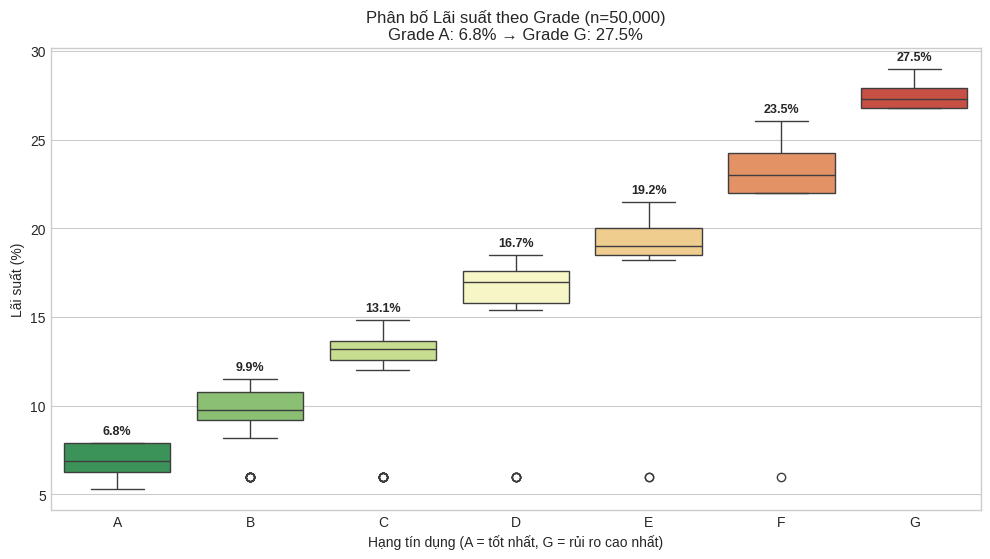


📌 INSIGHT: Lãi suất tăng mạnh theo Grade
   • Grade A: 6.8% (rủi ro thấp nhất)
   • Grade G: 27.5% (rủi ro cao nhất)
   • Chênh lệch: 20.7%



In [6]:
# Tính lãi suất theo Grade để chú thích
rate_by_grade = df.groupby('grade')['int_rate'].agg(['mean', 'min', 'max'])

# Boxplot: Lãi suất theo Grade
if 'grade' in df.columns and 'int_rate' in df.columns:
    plt.figure(figsize=(12, 6))
    
    # Tạo boxplot với chú thích
    bp = sns.boxplot(x='grade', y='int_rate', data=df, palette='RdYlGn_r', 
                     order=['A','B','C','D','E','F','G'])
    
    plt.title(f'Phân bố Lãi suất theo Grade (n={n_rows:,})\n'
              f'Grade A: {rate_by_grade.loc["A", "mean"]:.1f}% → Grade G: {rate_by_grade.loc["G", "mean"]:.1f}%')
    plt.xlabel('Hạng tín dụng (A = tốt nhất, G = rủi ro cao nhất)')
    plt.ylabel('Lãi suất (%)')
    
    # Thêm giá trị mean trên mỗi box
    for i, grade in enumerate(['A','B','C','D','E','F','G']):
        if grade in rate_by_grade.index:
            mean_val = rate_by_grade.loc[grade, 'mean']
            plt.text(i, rate_by_grade.loc[grade, 'max'] + 0.5, f'{mean_val:.1f}%', 
                     ha='center', fontsize=9, fontweight='bold')
    
    plt.savefig('outputs/06_boxplot_grade.png', dpi=150, bbox_inches='tight')
    plt.show()

# In insight
print(f"""
📌 INSIGHT: Lãi suất tăng mạnh theo Grade
   • Grade A: {rate_by_grade.loc['A', 'mean']:.1f}% (rủi ro thấp nhất)
   • Grade G: {rate_by_grade.loc['G', 'mean']:.1f}% (rủi ro cao nhất)
   • Chênh lệch: {rate_by_grade.loc['G', 'mean'] - rate_by_grade.loc['A', 'mean']:.1f}%
""")

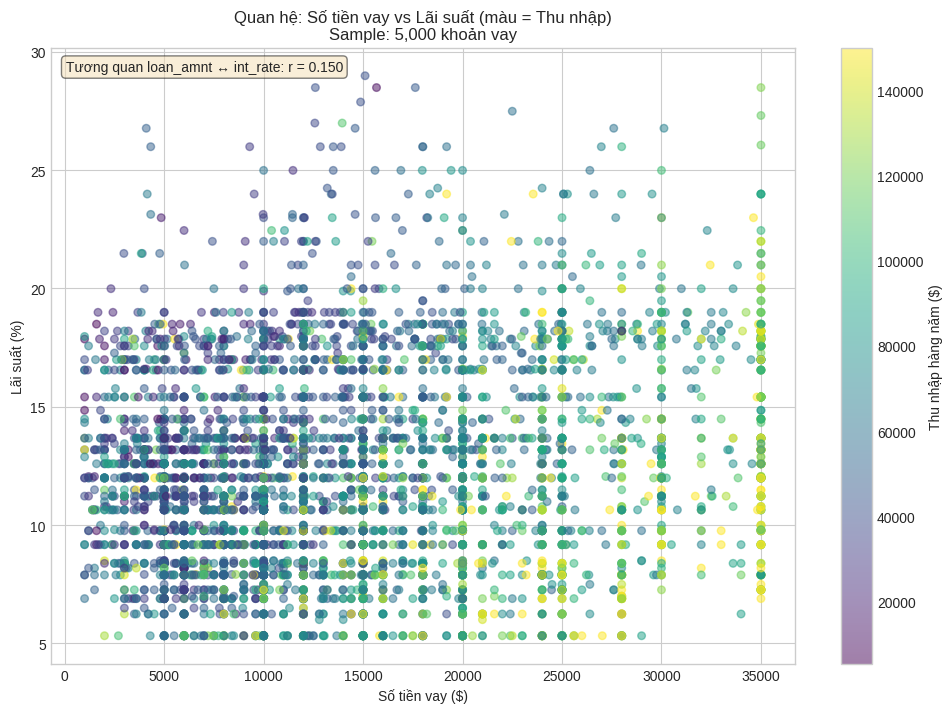

In [7]:
# Scatter Plot với nhiều chiều
if all(col in df.columns for col in ['loan_amnt', 'int_rate', 'annual_inc']):
    plt.figure(figsize=(12, 8))
    
    sample = df.sample(min(5000, len(df)), random_state=42)
    
    scatter = plt.scatter(
        sample['loan_amnt'], 
        sample['int_rate'],
        c=sample['annual_inc'].clip(upper=sample['annual_inc'].quantile(0.95)),
        cmap='viridis',
        alpha=0.5,
        s=30
    )
    plt.colorbar(scatter, label='Thu nhập hàng năm ($)')
    plt.xlabel('Số tiền vay ($)')
    plt.ylabel('Lãi suất (%)')
    plt.title(f'Quan hệ: Số tiền vay vs Lãi suất (màu = Thu nhập)\n'
              f'Sample: {len(sample):,} khoản vay')
    
    # Thêm chú thích
    corr = df['loan_amnt'].corr(df['int_rate'])
    plt.text(0.02, 0.98, f'Tương quan loan_amnt ↔ int_rate: r = {corr:.3f}', 
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.savefig('outputs/06_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

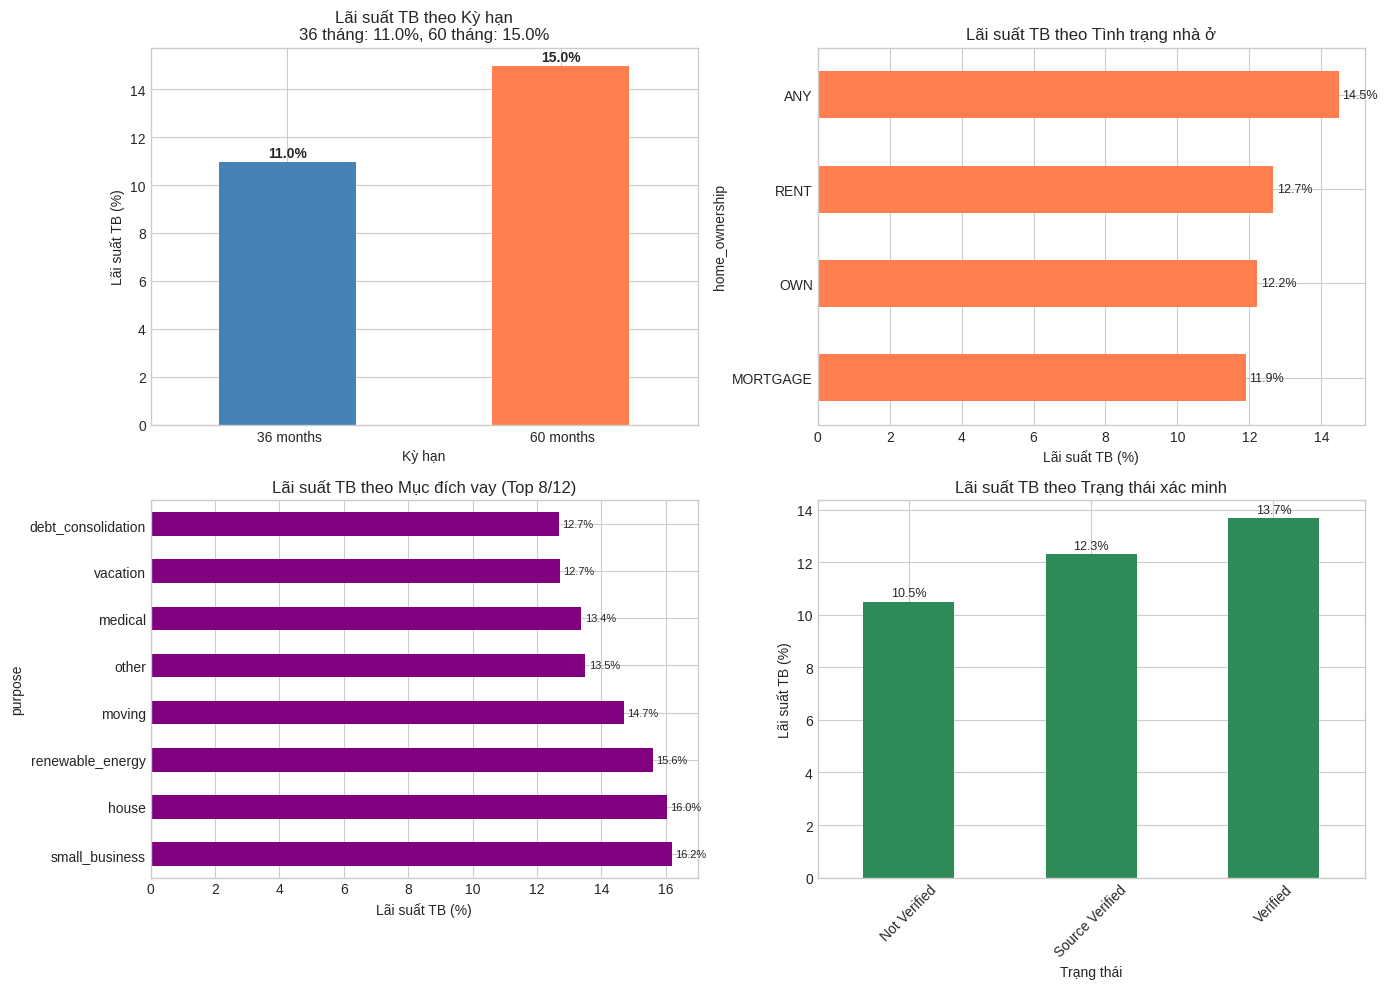

In [8]:
# Lãi suất theo các nhóm khác nhau
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By Term
if 'term' in df.columns and 'int_rate' in df.columns:
    ax = axes[0, 0]
    term_rates = df.groupby('term')['int_rate'].mean()
    bars = term_rates.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
    ax.set_title(f'Lãi suất TB theo Kỳ hạn\n36 tháng: {term_rates.iloc[0]:.1f}%, 60 tháng: {term_rates.iloc[1]:.1f}%')
    ax.set_xlabel('Kỳ hạn')
    ax.set_ylabel('Lãi suất TB (%)')
    ax.tick_params(axis='x', rotation=0)
    # Thêm giá trị
    for i, (idx, val) in enumerate(term_rates.items()):
        ax.text(i, val + 0.2, f'{val:.1f}%', ha='center', fontweight='bold')

# By Home Ownership
if 'home_ownership' in df.columns and 'int_rate' in df.columns:
    ax = axes[0, 1]
    ho_rates = df.groupby('home_ownership')['int_rate'].mean().sort_values()
    bars = ho_rates.plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Lãi suất TB theo Tình trạng nhà ở')
    ax.set_xlabel('Lãi suất TB (%)')
    # Thêm giá trị
    for i, (idx, val) in enumerate(ho_rates.items()):
        ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

# By Purpose (top 8)
if 'purpose' in df.columns and 'int_rate' in df.columns:
    ax = axes[1, 0]
    purpose_rates = df.groupby('purpose')['int_rate'].mean().sort_values(ascending=False).head(8)
    bars = purpose_rates.plot(kind='barh', ax=ax, color='purple')
    ax.set_title(f'Lãi suất TB theo Mục đích vay (Top 8/{df["purpose"].nunique()})')
    ax.set_xlabel('Lãi suất TB (%)')
    for i, (idx, val) in enumerate(purpose_rates.items()):
        ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8)

# By Verification Status
if 'verification_status' in df.columns and 'int_rate' in df.columns:
    ax = axes[1, 1]
    vs_rates = df.groupby('verification_status')['int_rate'].mean()
    bars = vs_rates.plot(kind='bar', ax=ax, color='seagreen')
    ax.set_title('Lãi suất TB theo Trạng thái xác minh')
    ax.set_xlabel('Trạng thái')
    ax.set_ylabel('Lãi suất TB (%)')
    ax.tick_params(axis='x', rotation=45)
    for i, (idx, val) in enumerate(vs_rates.items()):
        ax.text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/06_bivariate_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.5 Multivariate Analysis - Phân tích đa biến

In [9]:
print("=" * 70)
print("🌍 MULTIVARIATE ANALYSIS - PHÂN TÍCH ĐA BIẾN")
print("=" * 70)
print("Kiểm tra mối quan hệ giữa ba hoặc nhiều biến")

🌍 MULTIVARIATE ANALYSIS - PHÂN TÍCH ĐA BIẾN
Kiểm tra mối quan hệ giữa ba hoặc nhiều biến


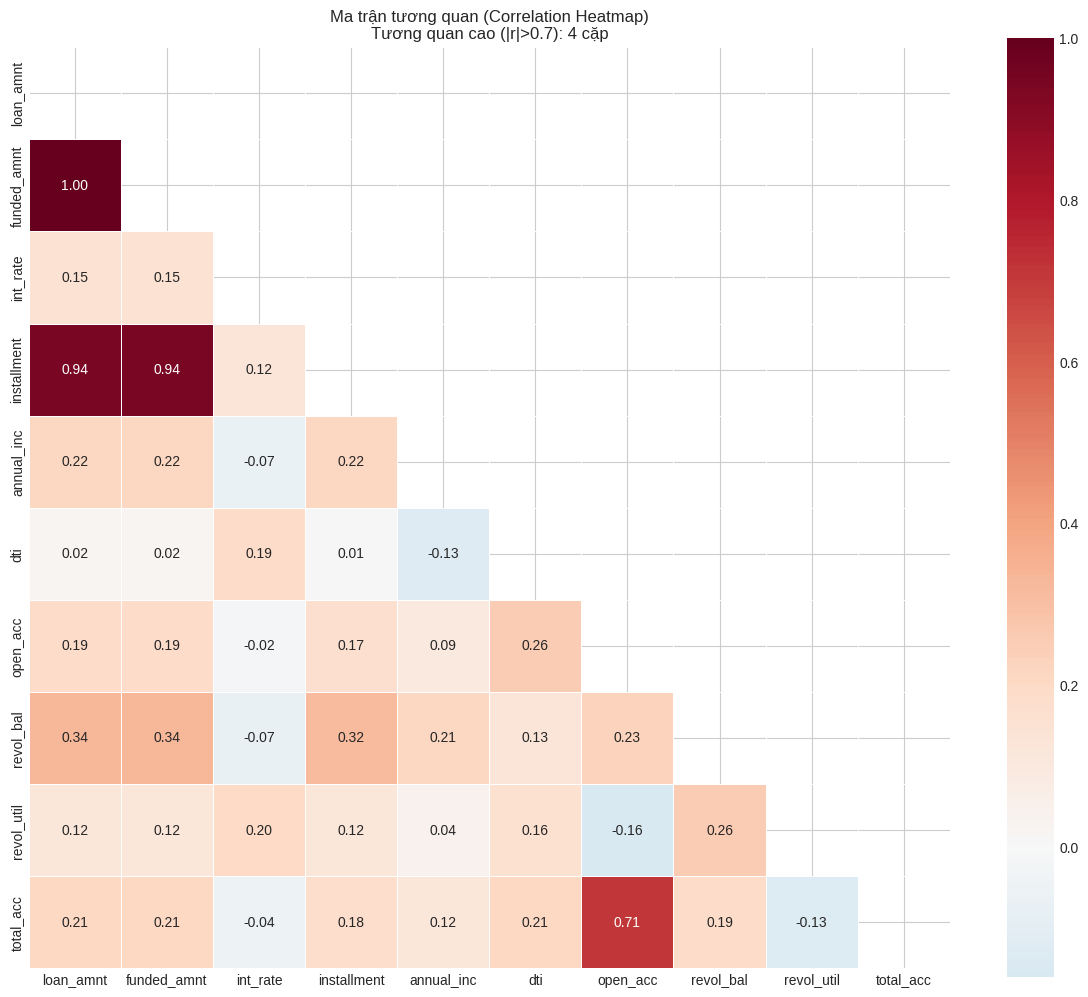


📌 CÁC CẶP BIẾN CÓ TƯƠNG QUAN CAO (|r| > 0.7):
   • loan_amnt ↔ funded_amnt: r = 1.000
   • loan_amnt ↔ installment: r = 0.944
   • funded_amnt ↔ installment: r = 0.944
   • open_acc ↔ total_acc: r = 0.713


In [10]:
# Heatmap tương quan với chú thích
num_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 
            'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc']
num_cols = [col for col in num_cols if col in df.columns]

if len(num_cols) > 3:
    plt.figure(figsize=(12, 10))
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Tìm tương quan cao
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i,j]) > 0.7:
                high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))
    
    sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, 
                fmt='.2f', square=True, linewidths=0.5)
    
    title = 'Ma trận tương quan (Correlation Heatmap)\n'
    if high_corr:
        title += f'Tương quan cao (|r|>0.7): {len(high_corr)} cặp'
    plt.title(title)
    plt.tight_layout()
    plt.savefig('outputs/06_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # In insight
    if high_corr:
        print("\n📌 CÁC CẶP BIẾN CÓ TƯƠNG QUAN CAO (|r| > 0.7):")
        for col1, col2, r in high_corr:
            print(f"   • {col1} ↔ {col2}: r = {r:.3f}")

## 6.6 Phân tích theo biến mục tiêu

🎯 PHÂN TÍCH THEO BIẾN MỤC TIÊU


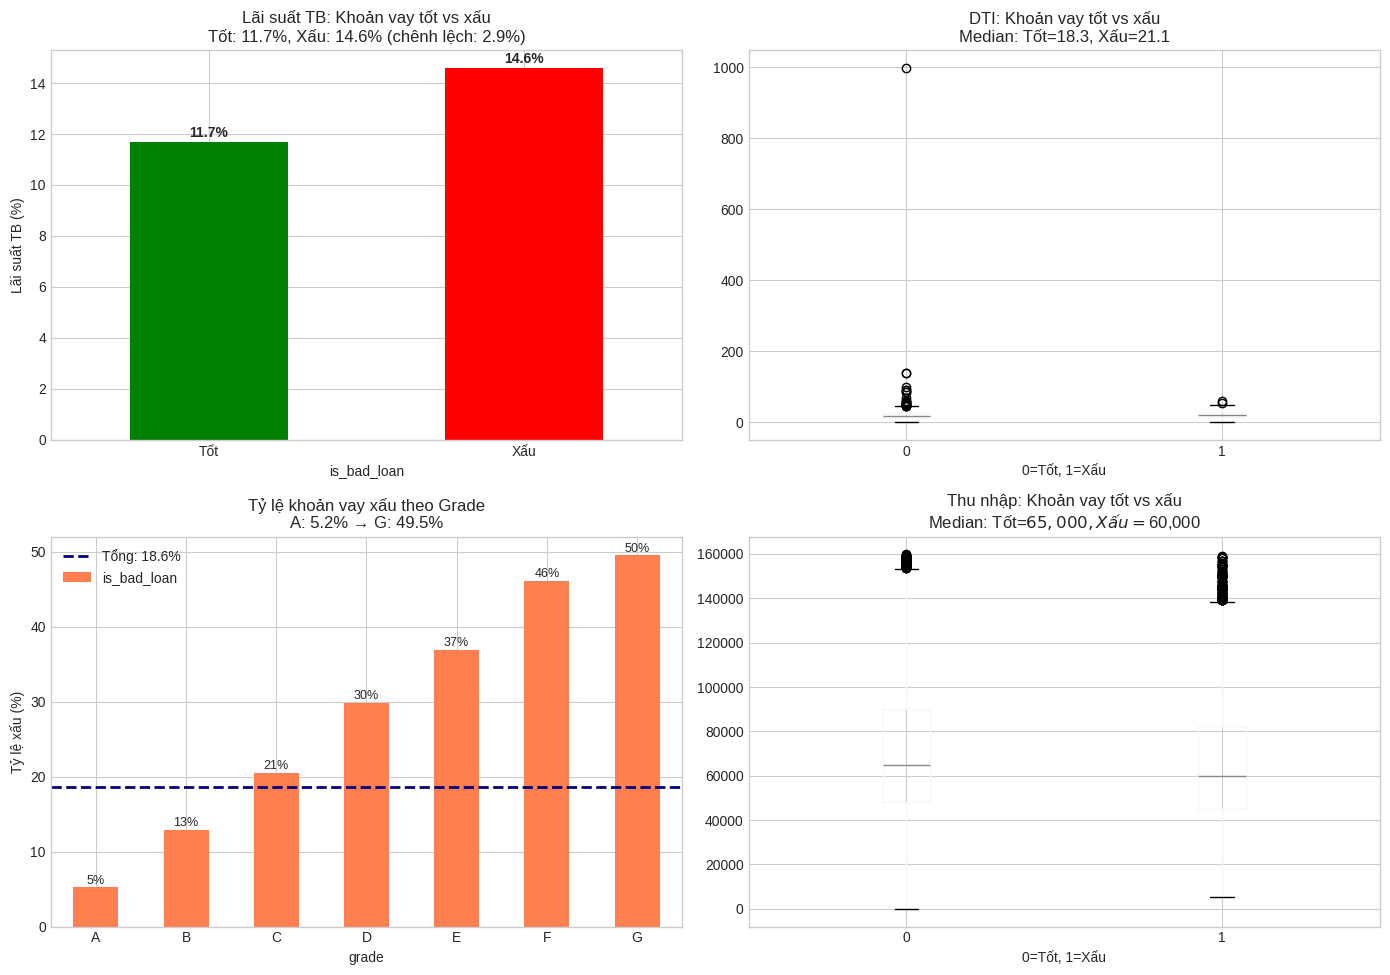


📌 INSIGHT TỪ PHÂN TÍCH BIẾN MỤC TIÊU:
   • Tỷ lệ khoản vay xấu tổng: 18.62%
   • Khoản vay xấu có lãi suất cao hơn: 14.6% vs 11.7%
   • Grade A: 5.2% xấu (rủi ro thấp)
   • Grade G: 49.5% xấu (rủi ro gấp 9x)
   • Thu nhập median của khoản vay tốt cao hơn xấu



In [11]:
if 'is_bad_loan' in df.columns or 'loan_status' in df.columns:
    print("=" * 70)
    print("🎯 PHÂN TÍCH THEO BIẾN MỤC TIÊU")
    print("=" * 70)
    
    if 'is_bad_loan' not in df.columns:
        bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']
        df['is_bad_loan'] = df['loan_status'].isin(bad_statuses).astype(int)
    
    bad_loan_rate = df['is_bad_loan'].mean() * 100
    bad_rate_by_grade = df.groupby('grade')['is_bad_loan'].mean() * 100
    
    # Lãi suất theo loan type
    rate_good = df[df['is_bad_loan']==0]['int_rate'].mean()
    rate_bad = df[df['is_bad_loan']==1]['int_rate'].mean()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Lãi suất theo loan status
    ax = axes[0, 0]
    rates = df.groupby('is_bad_loan')['int_rate'].mean()
    bars = rates.plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_xticklabels(['Tốt', 'Xấu'], rotation=0)
    ax.set_title(f'Lãi suất TB: Khoản vay tốt vs xấu\n'
                 f'Tốt: {rate_good:.1f}%, Xấu: {rate_bad:.1f}% (chênh lệch: {rate_bad-rate_good:.1f}%)')
    ax.set_ylabel('Lãi suất TB (%)')
    for i, val in enumerate(rates.values):
        ax.text(i, val + 0.2, f'{val:.1f}%', ha='center', fontweight='bold')
    
    # DTI theo loan status
    ax = axes[0, 1]
    df.boxplot(column='dti', by='is_bad_loan', ax=ax)
    dti_good = df[df['is_bad_loan']==0]['dti'].median()
    dti_bad = df[df['is_bad_loan']==1]['dti'].median()
    ax.set_title(f'DTI: Khoản vay tốt vs xấu\nMedian: Tốt={dti_good:.1f}, Xấu={dti_bad:.1f}')
    ax.set_xlabel('0=Tốt, 1=Xấu')
    plt.suptitle('')  # Remove auto title
    
    # Bad loan rate theo Grade
    ax = axes[1, 0]
    if 'grade' in df.columns:
        bars = bad_rate_by_grade.sort_index().plot(kind='bar', ax=ax, color='coral')
        ax.axhline(bad_loan_rate, color='navy', linestyle='--', linewidth=2, 
                   label=f'Tổng: {bad_loan_rate:.1f}%')
        ax.set_title(f'Tỷ lệ khoản vay xấu theo Grade\n'
                     f'A: {bad_rate_by_grade.loc["A"]:.1f}% → G: {bad_rate_by_grade.loc["G"]:.1f}%')
        ax.set_ylabel('Tỷ lệ xấu (%)')
        ax.tick_params(axis='x', rotation=0)
        ax.legend()
        for i, (idx, val) in enumerate(bad_rate_by_grade.sort_index().items()):
            ax.text(i, val + 0.5, f'{val:.0f}%', ha='center', fontsize=9)
    
    # Annual income theo loan status
    ax = axes[1, 1]
    df_clean = df[df['annual_inc'] < df['annual_inc'].quantile(0.95)]
    inc_good = df_clean[df_clean['is_bad_loan']==0]['annual_inc'].median()
    inc_bad = df_clean[df_clean['is_bad_loan']==1]['annual_inc'].median()
    df_clean.boxplot(column='annual_inc', by='is_bad_loan', ax=ax)
    ax.set_title(f'Thu nhập: Khoản vay tốt vs xấu\nMedian: Tốt=${inc_good:,.0f}, Xấu=${inc_bad:,.0f}')
    ax.set_xlabel('0=Tốt, 1=Xấu')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.savefig('outputs/06_target_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # In insights
    print(f"""
📌 INSIGHT TỪ PHÂN TÍCH BIẾN MỤC TIÊU:
   • Tỷ lệ khoản vay xấu tổng: {bad_loan_rate:.2f}%
   • Khoản vay xấu có lãi suất cao hơn: {rate_bad:.1f}% vs {rate_good:.1f}%
   • Grade A: {bad_rate_by_grade.loc['A']:.1f}% xấu (rủi ro thấp)
   • Grade G: {bad_rate_by_grade.loc['G']:.1f}% xấu (rủi ro gấp {bad_rate_by_grade.loc['G']/bad_rate_by_grade.loc['A']:.0f}x)
   • Thu nhập median của khoản vay tốt cao hơn xấu
""")

## 6.7 Tổng kết Bước 6

In [12]:
print("=" * 70)
print("📋 TỔNG KẾT BƯỚC 6: TRỰC QUAN HÓA MỐI QUAN HỆ")
print("=" * 70)

# Tính các metrics để báo cáo
if 'is_bad_loan' in df.columns:
    print(f"""
✅ ĐÃ HOÀN THÀNH:
   • Univariate Analysis: Histogram, KDE với mean/median annotations
   • Bivariate Analysis: Boxplot, Scatter plot với correlation
   • Multivariate Analysis: Correlation heatmap với {len(high_corr) if 'high_corr' in dir() else 0} cặp tương quan cao
   • Phân tích theo biến mục tiêu (is_bad_loan)

📊 PHÁT HIỆN CHÍNH TỪ DỮ LIỆU:
   1. Lãi suất tăng đều theo Grade: A ({rate_by_grade.loc['A', 'mean']:.1f}%) → G ({rate_by_grade.loc['G', 'mean']:.1f}%)
   2. Khoản vay 60 tháng có lãi suất cao hơn 36 tháng
   3. Tỷ lệ khoản vay xấu: A ({bad_rate_by_grade.loc['A']:.1f}%) → G ({bad_rate_by_grade.loc['G']:.1f}%)
   4. Khoản vay xấu có int_rate cao hơn ({rate_bad:.1f}% vs {rate_good:.1f}%)
   5. loan_amnt ≈ funded_amnt ≈ installment (multicollinearity)

💡 GỢI Ý CHO MODELING:
   • Grade là feature quan trọng nhất
   • Loại bỏ funded_amnt (trùng loan_amnt)
   • Xem xét tạo loan_to_income ratio

📝 BƯỚC TIẾP THEO:
   → Bước 7: Xử lý ngoại lệ (Outliers)
""")

📋 TỔNG KẾT BƯỚC 6: TRỰC QUAN HÓA MỐI QUAN HỆ

✅ ĐÃ HOÀN THÀNH:
   • Univariate Analysis: Histogram, KDE với mean/median annotations
   • Bivariate Analysis: Boxplot, Scatter plot với correlation
   • Multivariate Analysis: Correlation heatmap với 4 cặp tương quan cao
   • Phân tích theo biến mục tiêu (is_bad_loan)

📊 PHÁT HIỆN CHÍNH TỪ DỮ LIỆU:
   1. Lãi suất tăng đều theo Grade: A (6.8%) → G (27.5%)
   2. Khoản vay 60 tháng có lãi suất cao hơn 36 tháng
   3. Tỷ lệ khoản vay xấu: A (5.2%) → G (49.5%)
   4. Khoản vay xấu có int_rate cao hơn (14.6% vs 11.7%)
   5. loan_amnt ≈ funded_amnt ≈ installment (multicollinearity)

💡 GỢI Ý CHO MODELING:
   • Grade là feature quan trọng nhất
   • Loại bỏ funded_amnt (trùng loan_amnt)
   • Xem xét tạo loan_to_income ratio

📝 BƯỚC TIẾP THEO:
   → Bước 7: Xử lý ngoại lệ (Outliers)

